[Default of Credit Card Clients UCI](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

This notebook is used exclusively for exploratory analysis and
design validation. All production code is implemented in /src.

# 0. Setup & Import

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

# 1. Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients.xls


# 2. Basic Sanity Check

In [ ]:
df = pd.read_excel("default of credit card clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


# 3. Column Handling

In [ ]:
df.columns = (
    df.columns
      .str.lower()
)

df.head()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
target_col = "default_payment_next_month"

# 4. Missing Value & Data Quality

In [ ]:
df.isna().sum()

,0
id,0
limit_bal,0
sex,0
education,0
marriage,0
age,0
pay_0,0
pay_2,0
pay_3,0
pay_4,0


In [ ]:
(df == 0).sum().sort_values(ascending=False).head(10)

,0
default_payment_next_month,23364
pay_5,16947
pay_4,16455
pay_6,16286
pay_3,15764
pay_2,15730
pay_0,14737
pay_amt6,7173
pay_amt5,6703
pay_amt4,6408


# 5. Target Distribution

In [ ]:
df[target_col].value_counts(normalize=True)

,proportion
default_payment_next_month,
0,0.7788
1,0.2212


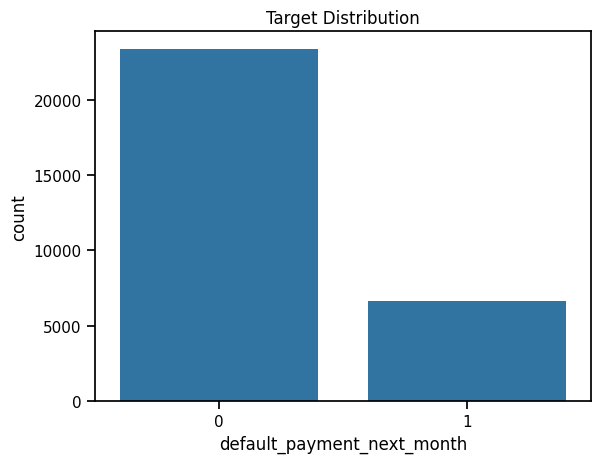

In [ ]:
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

# 6. Time/Sequential Columns

In [ ]:
bill_cols = [c for c in df.columns if "bill_amt" in c]
pay_cols  = [c for c in df.columns if "pay_amt" in c]

bill_cols, pay_cols

(['bill_amt1',
  'bill_amt2',
  'bill_amt3',
  'bill_amt4',
  'bill_amt5',
  'bill_amt6'],
 ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'])

# 7. Aggregate View

In [ ]:
df["avg_bill"] = df[bill_cols].mean(axis=1)
df["std_bill"] = df[bill_cols].std(axis=1)

df["avg_pay"] = df[pay_cols].mean(axis=1)

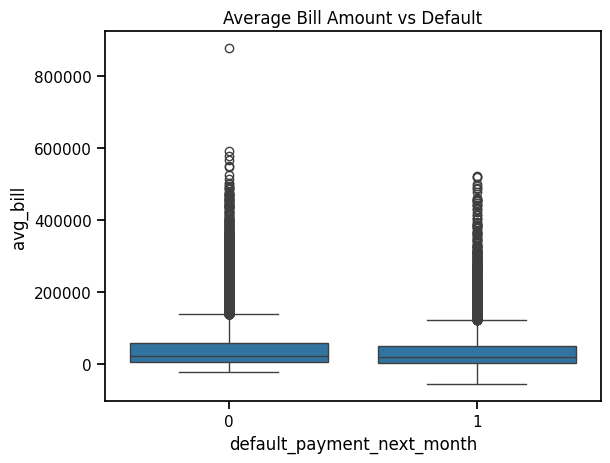

In [ ]:
sns.boxplot(
    x=target_col,
    y="avg_bill",
    data=df
)
plt.title("Average Bill Amount vs Default")
plt.show()

# 8. Correlation

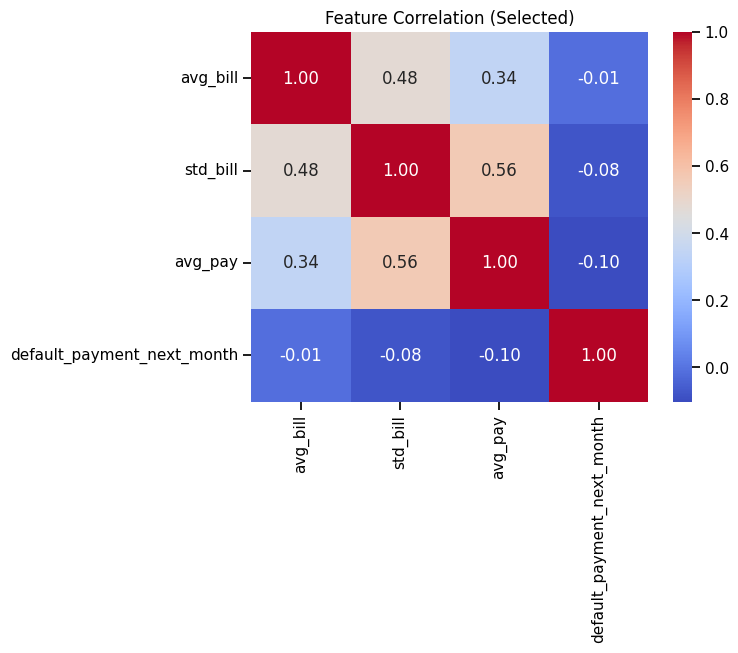

In [ ]:
corr_cols = ["avg_bill", "std_bill", "avg_pay", target_col]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation (Selected)")
plt.show()

# 9. Transactional View Simulation

In [ ]:
records = []

for i, row in df.iterrows():
    for t, col in enumerate(bill_cols):
        records.append({
            "user_id": row["id"],
            "month_idx": t,
            "bill_amt": row[col],
            "pay_amt": row[pay_cols[t]],
            "default": row[target_col]
        })

txn_df = pd.DataFrame(records)
txn_df.head()

,user_id,month_idx,bill_amt,pay_amt,default
0,1.0,0,3913.0,0.0,1.0
1,1.0,1,3102.0,689.0,1.0
2,1.0,2,689.0,0.0,1.0
3,1.0,3,0.0,0.0,1.0
4,1.0,4,0.0,0.0,1.0


In [ ]:
txn_df.shape

(180000, 5)

# 10. Bottleneck Demonstration

In [ ]:
%timeit txn_df.groupby("user_id")["bill_amt"].rolling(3).mean()

863 ms ± 193 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# 11. Save Processed Data

In [ ]:
txn_df = txn_df.sort_values(["user_id", "month_idx"])
txn_df.to_csv("transactions_processed.csv", index=False)

In [ ]:
files.download("transactions_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 12. EDA Summary

**1. Data Landscape & Health Check**
Hasil audit dataset Credit Card Default yang memuat 30.000 nasabah dengan 24 fitur mentah (demografi, riwayat pembayaran, tagihan).
*   **Volume**: 30.000 baris. Terlihat kecil, tetapi operasi agregasi rolling window (seperti avg_bill atau std_bill per nasabah) mengubah ini menjadi masalah komputasi O(N*T) yang berat.
* **Target Balance**: Terjadi ketimpangan kelas yang moderat. Non-Default (0): 77.88%. Default (1): 22.12%. Implikasi: Model butuh metrik evaluasi yang lebih nuansa dari sekadar akurasi (misal: ROC-AUC atau F1-Score), dan strategi sampling mungkin diperlukan.
* **Integritas Data**: Tidak ditemukan missing values eksplisit pada statistik deskriptif, namun rentang nilai PAY_n (-2 hingga 8) dan BILL_AMT (negatif hingga jutaan) menunjukkan variasi perilaku finansial yang ekstrem.

**2. Univariate Analysis**:
Distribusi fitur finansial menunjukkan skewness yang parah. Inilah mengapa model linear biasa akan gagal, dan mengapa kita butuh feature engineering.
*   **Outliers adalah Norma**: Melihat Boxplot avg_bill, terdapat ribuan outliers di sisi atas. Nasabah dengan tagihan rata-rata >400.000 ada di kedua kelas (Default & Non-Default).
*   **Limit Balance**: Rentang LIMIT_BAL sangat lebar (10k - 1M), mencerminkan campuran nasabah low-tier hingga high-net-worth.

**3. Multivariate Analysis**:
Di sinilah letak pembenaran untuk proyek Numba.
*   **Korelasi Linear yang Lemah**: Berdasarkan Heatmap, fitur agregasi seperti avg_bill (-0.01) dan std_bill (-0.08) memiliki korelasi linear yang sangat lemah terhadap target default_payment_next_month.
*   **Multikolinearitas Internal**: avg_bill dan std_bill berkorelasi moderat (0.48). avg_pay dan avg_bill berkorelasi (0.34).
*   **Interpretasi Kritis**: Fakta bahwa korelasi linear terhadap target rendah menunjukkan bahwa risiko kredit adalah fungsi non-linear. Kita tidak bisa hanya melihat angka mentah; kita perlu patterns (pola). Inilah sebabnya kita perlu membuat derived features yang kompleks (seperti variabilitas pembayaran, tren kenaikan tagihan) yang memakan waktu komputasi tinggi—membenarkan kebutuhan akan engine Numba.

# 13. Key Findings & Engineering Impact

**1. Signal is Buried in Volatility**
Analisis Boxplot menunjukkan bahwa median tagihan (avg_bill) antara nasabah yang bayar (0) dan gagal bayar (1) hampir identik.
*   **Insight**: Besaran tagihan semata bukan prediktor kuat. Prediktor sebenarnya kemungkinan besar bersembunyi dalam volatilitas (seberapa sering tagihan naik turun) dan konsistensi pembayaran.
*   **Action**: Diperlukan fitur statistik orde tinggi (rolling std, rolling mean) untuk menangkap sinyal ini.

**2. The "Numba" Justification**
Menghitung fitur statistik historis (seperti avg_bill dan std_bill yang kamu plot di heatmap) pada data transaksional adalah bottleneck utama.
*   **Benchmark Awal**: Menggunakan Pandas biasa untuk operasi baris-per-baris. Implementasi standar menggunakan groupby().rolling() mencatat waktu 863 ms ± 193 ms per loop. Ini sangat lambat karena adanya overhead python object pada setiap grup user.

**3. Class Imbalance Strategy**
Dengan rasio default hanya 22%, akurasi model bisa menipu.
*   **Rekomendasi**: Gunakan scale_pos_weight pada XGBoost/LightGBM atau teknik SMOTE saat training pipeline, karena EDA menunjukkan kelas minoritas (Default) memiliki fitur yang "tumpang tindih" dengan kelas mayoritas.